# 🔧 Prompted Segmentation for Drywall QA — CLIPSeg Fine-Tuning

**Model:** CLIPSeg (Lüddecke & Ecker, CVPR 2022) — CLIP ViT backbone + FiLM transformer decoder  
**Task:** Text-conditioned binary segmentation  
**Datasets:**
- Dataset 1: Drywall taping areas (`objectdetect-pu6rn/drywall-join-detect`)
- Dataset 2: Wall cracks (`university-bswxt/crack-bphdr`)

**Seeds fixed for reproducibility:** `SEED = 42`

## 0. Install Dependencies

In [2]:
%%capture
!pip install roboflow transformers torch torchvision Pillow matplotlib scikit-learn tqdm python-dotenv

## 1. Seed & Imports

In [3]:
import os, json, random, time, shutil
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from tqdm import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128


## 2. Download Datasets from Roboflow (COCO Segmentation format)

In [4]:
from roboflow import Roboflow


# Option B: from Colab secrets (recommended)
from google.colab import userdata
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# ── Dataset 1: Drywall joins / taping area ────────────────────────────────────
print("Downloading Dataset 1: Drywall joins...")
project1  = rf.workspace("objectdetect-pu6rn").project("drywall-join-detect")
dataset1  = project1.version(1).download("yolov8")
DRYWALL_DIR = dataset1.location
print("Drywall dataset at:", DRYWALL_DIR)

# ── Dataset 2: Cracks ─────────────────────────────────────────────────────────
print("\nDownloading Dataset 2: Cracks...")
project2 = rf.workspace("university-bswxt").project("crack-bphdr")
dataset2 = project2.version(1).download("coco-segmentation")
CRACK_DIR = dataset2.location
print("Crack dataset at:", CRACK_DIR)

loading Roboflow workspace...
loading Roboflow project...
Drywall dataset at: /content/Drywall-Join-Detect-1

loading Roboflow workspace...
loading Roboflow project...
Crack dataset at: /content/crack-1


In [5]:
import os

print("Drywall structure:")
for root, dirs, files in os.walk(DRYWALL_DIR):
    print(root, "->", dirs)
    break

Drywall structure:
/content/Drywall-Join-Detect-1 -> ['train', 'valid']


In [6]:
print(os.listdir(os.path.join(DRYWALL_DIR, "train")))

['masks', 'images', 'labels']


In [7]:
import os
import cv2
import numpy as np

def yolo_to_mask_split(dataset_dir, split):
    images_dir = os.path.join(dataset_dir, split, "images")
    labels_dir = os.path.join(dataset_dir, split, "labels")
    mask_dir   = os.path.join(dataset_dir, split, "masks")

    if not os.path.exists(images_dir):
        print(f"[WARN] No images for {split}")
        return

    os.makedirs(mask_dir, exist_ok=True)

    for img_file in os.listdir(images_dir):
        if not img_file.endswith((".jpg", ".png")):
            continue

        img_path = os.path.join(images_dir, img_file)
        label_path = os.path.join(
            labels_dir,
            img_file.replace(".jpg", ".txt").replace(".png", ".txt")
        )

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w, _ = img.shape
        mask = np.zeros((h, w), dtype=np.uint8)

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, x, y, bw, bh = map(float, line.strip().split())

                    x_center = int(x * w)
                    y_center = int(y * h)
                    box_w = int(bw * w)
                    box_h = int(bh * h)

                    x1 = max(0, int(x_center - box_w / 2))
                    y1 = max(0, int(y_center - box_h / 2))
                    x2 = min(w, int(x_center + box_w / 2))
                    y2 = min(h, int(y_center + box_h / 2))

                    mask[y1:y2, x1:x2] = 255

        cv2.imwrite(os.path.join(mask_dir, img_file), mask)

    print(f"[DONE] {split} masks created")

In [8]:
for split in ["train", "valid"]:
    yolo_to_mask_split(DRYWALL_DIR, split)

[DONE] train masks created
[DONE] valid masks created


In [9]:
print(os.listdir(os.path.join(DRYWALL_DIR, "train")))

['masks', 'images', 'labels']


## 3. COCO Segmentation → Binary Masks

In [10]:
import os, json, cv2
import numpy as np
from collections import defaultdict
from PIL import Image, ImageDraw


# ─────────────────────────────────────────────────────────────
# 1. COCO → mask (for crack dataset)
# ─────────────────────────────────────────────────────────────
def polygon_to_mask(segmentation, height, width):
    mask = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask)

    for poly in segmentation:
        if len(poly) >= 6:
            xy = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
            draw.polygon(xy, fill=255)

    return np.array(mask)


def load_coco_split(dataset_dir, split="train"):
    ann_file = os.path.join(dataset_dir, split, "_annotations.coco.json")
    img_dir  = os.path.join(dataset_dir, split)

    if not os.path.exists(ann_file):
        return []

    with open(ann_file) as f:
        coco = json.load(f)

    id2img   = {img["id"]: img for img in coco["images"]}
    img2anns = defaultdict(list)

    for ann in coco["annotations"]:
        if ann.get("segmentation"):
            img2anns[ann["image_id"]].append(ann)

    records = []

    for img_id, anns in img2anns.items():
        info = id2img[img_id]
        img_path = os.path.join(img_dir, info["file_name"])

        if not os.path.exists(img_path):
            continue

        h, w = info["height"], info["width"]
        combined = np.zeros((h, w), dtype=np.uint8)

        for ann in anns:
            m = polygon_to_mask(ann["segmentation"], h, w)
            combined = np.maximum(combined, m)

        records.append({
            "image_path": img_path,
            "mask": combined,
            "image_id": img_id,
        })

    return records


# ─────────────────────────────────────────────────────────────
# 2. YOLO → mask loader (for drywall dataset)
# ─────────────────────────────────────────────────────────────
def load_yolo_mask_split(dataset_dir, split="train"):
    img_dir  = os.path.join(dataset_dir, split, "images")
    mask_dir = os.path.join(dataset_dir, split, "masks")

    if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
        return []

    records = []

    for img_file in os.listdir(img_dir):
        if not img_file.endswith((".jpg", ".png")):
            continue

        img_path  = os.path.join(img_dir, img_file)
        mask_path = os.path.join(mask_dir, img_file)

        if not os.path.exists(mask_path):
            continue

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        records.append({
            "image_path": img_path,
            "mask": mask,
            "image_id": img_file,
        })

    return records


# ─────────────────────────────────────────────────────────────
# 3. SMART LOADER (auto-detect format)
# ─────────────────────────────────────────────────────────────
def load_split(dataset_dir, split="train"):
    # If COCO file exists → use COCO loader
    coco_path = os.path.join(dataset_dir, split, "_annotations.coco.json")

    if os.path.exists(coco_path):
        return load_coco_split(dataset_dir, split)
    else:
        return load_yolo_mask_split(dataset_dir, split)


# ─────────────────────────────────────────────────────────────
# 4. LOAD DATASETS (clean + unified)
# ─────────────────────────────────────────────────────────────
print("Loading drywall records...")
drywall_train = load_split(DRYWALL_DIR, "train")
drywall_valid = load_split(DRYWALL_DIR, "valid")
drywall_test  = load_split(DRYWALL_DIR, "test")

print("Loading crack records...")
crack_train = load_split(CRACK_DIR, "train")
crack_valid = load_split(CRACK_DIR, "valid")
crack_test  = load_split(CRACK_DIR, "test")


# ─────────────────────────────────────────────────────────────
# 5. fallback logic (same as before)
# ─────────────────────────────────────────────────────────────
if not drywall_test:
    print("[INFO] Drywall test split empty — using valid as test.")
    drywall_test = drywall_valid

if not crack_test:
    print("[INFO] Crack test split empty — using valid as test.")
    crack_test = crack_valid


print(f"\nDrywall  — train:{len(drywall_train)}  valid:{len(drywall_valid)}  test:{len(drywall_test)}")
print(f"Crack    — train:{len(crack_train)}    valid:{len(crack_valid)}    test:{len(crack_test)}")

Loading drywall records...
Loading crack records...
[INFO] Drywall test split empty — using valid as test.

Drywall  — train:936  valid:250  test:250
Crack    — train:1239    valid:0    test:312


## 4. Prompt Mapping & Dataset Class

In [25]:
DRYWALL_PROMPTS = [
    "segment taping area",
    "segment joint tape",
    "segment drywall seam",
    "segment drywall joint",
]

CRACK_PROMPTS = [
    "segment crack",
    "segment wall crack",
    "segment surface crack",
    "segment concrete crack",
]

CANONICAL = {
    "drywall": "segment taping area",
    "crack":   "segment crack",
}


class DrywallQADataset(Dataset):
    def __init__(self, records, prompt_pool, processor, img_size=352, augment=False):
        self.records   = records
        self.prompts   = prompt_pool
        self.processor = processor
        self.img_size  = img_size
        self.augment   = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec   = self.records[idx]

        image = Image.open(rec["image_path"]).convert("RGB")
        mask  = Image.fromarray(rec["mask"]).resize(
            (self.img_size, self.img_size), Image.NEAREST
        )

        # optional augmentation
        if self.augment and random.random() > 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
            mask  = mask.transpose(Image.FLIP_LEFT_RIGHT)

        prompt = random.choice(self.prompts)

        # 🔥 FIXED TOKENIZATION (THIS WAS THE BUG)
        enc = self.processor(
            text=prompt,
            images=image,
            return_tensors="pt",
            padding="max_length",   # ✅ FIX
            truncation=True,        # ✅ FIX
            max_length=20           # ✅ FIX
        )

        pixel_values = enc["pixel_values"].squeeze(0)    # C H W
        input_ids    = enc["input_ids"].squeeze(0)       # fixed length
        attn_mask    = enc["attention_mask"].squeeze(0)

        gt = torch.tensor(np.array(mask), dtype=torch.float32) / 255.0

        return {
            "pixel_values":   pixel_values,
            "input_ids":      input_ids,
            "attention_mask": attn_mask,
            "gt_mask":        gt,
        }

## 5. Load CLIPSeg

In [26]:
MODEL_NAME = "CIDAS/clipseg-rd64-refined"

processor = CLIPSegProcessor.from_pretrained(MODEL_NAME)
model     = CLIPSegForImageSegmentation.from_pretrained(MODEL_NAME)
model     = model.to(DEVICE)

# Freeze the CLIP backbone — only fine-tune the decoder
for name, param in model.named_parameters():
    if "clip" in name.lower():
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params : 1,127,009 / 150,747,746  (0.7%)


## 6. DataLoaders

In [27]:
IMG_SIZE   = 352
BATCH_SIZE = 4
# num_workers=0 is safest on Colab; set to 2 if your runtime supports it
NUM_WORKERS = 0

def make_loader(records_d, records_c, processor, split="train"):
    """Combine drywall + crack records into one loader."""
    aug  = (split == "train")
    ds_d = DrywallQADataset(records_d, DRYWALL_PROMPTS, processor, IMG_SIZE, augment=aug)
    ds_c = DrywallQADataset(records_c, CRACK_PROMPTS,   processor, IMG_SIZE, augment=aug)
    combined = torch.utils.data.ConcatDataset([ds_d, ds_c])
    return DataLoader(
        combined,
        batch_size  = BATCH_SIZE,
        shuffle     = (split == "train"),
        num_workers = NUM_WORKERS,
        pin_memory  = (DEVICE.type == "cuda"),
        worker_init_fn = lambda wid: np.random.seed(SEED + wid),
    )

train_loader = make_loader(drywall_train, crack_train, processor, "train")
valid_loader = make_loader(drywall_valid, crack_valid, processor, "valid")
test_loader  = make_loader(drywall_test,  crack_test,  processor, "test")

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 544
Valid batches : 63
Test  batches : 141


## 7. Loss Functions & Metrics

In [28]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred   = torch.sigmoid(pred).view(-1)
        target = target.view(-1)
        inter  = (pred * target).sum()
        return 1 - (2 * inter + self.smooth) / (pred.sum() + target.sum() + self.smooth)


class CombinedLoss(nn.Module):
    def __init__(self, bce_w=0.5, dice_w=0.5):
        super().__init__()
        self.bce      = nn.BCEWithLogitsLoss()
        self.dice     = DiceLoss()
        self.bce_w    = bce_w
        self.dice_w   = dice_w

    def forward(self, pred, target):
        return self.bce_w * self.bce(pred, target) + self.dice_w * self.dice(pred, target)


@torch.no_grad()
def compute_metrics(pred_logits, gt_mask, threshold=0.5):
    """
    Returns mean mIoU and Dice for a batch.
    Accepts any shape — flattens to (B, -1) internally.
    """
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    gt   = gt_mask.float()

    pred = pred.view(pred.size(0), -1)
    gt   = gt.view(gt.size(0), -1)

    inter = (pred * gt).sum(dim=1)
    union = (pred + gt - pred * gt).sum(dim=1).clamp(min=1e-6)
    iou   = (inter / union).mean().item()
    dice  = (2 * inter / (pred.sum(dim=1) + gt.sum(dim=1) + 1e-6)).mean().item()
    return iou, dice


criterion = CombinedLoss(bce_w=0.5, dice_w=0.5)
print("Loss & metrics ready.")

Loss & metrics ready.


## 8. Training Loop

In [29]:
import matplotlib.pyplot as plt

EPOCHS = 15
LR     = 3e-4

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

os.makedirs("checkpoints", exist_ok=True)

history = {
    "train_loss": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": []
}

best_val_iou = 0.0
train_start  = time.time()

# 🔥 EARLY STOPPING PARAMS
early_stop_patience = 3
no_improve_epochs = 0


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_iou, total_dice, n = 0, 0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, leave=False, desc=("Train" if train else "Valid")):
            pixel_values = batch["pixel_values"].to(DEVICE)
            input_ids    = batch["input_ids"].to(DEVICE)
            attn_mask    = batch["attention_mask"].to(DEVICE)
            gt_mask      = batch["gt_mask"].to(DEVICE)

            outputs = model(
                pixel_values = pixel_values,
                input_ids    = input_ids,
                attention_mask = attn_mask,
            )

            logits = outputs.logits
            if logits.dim() == 4:
                logits = logits.squeeze(1)

            gt_h, gt_w = gt_mask.shape[-2], gt_mask.shape[-1]
            logits = F.interpolate(
                logits.unsqueeze(1),
                size=(gt_h, gt_w),
                mode="bilinear",
                align_corners=False
            ).squeeze(1)

            loss = criterion(logits, gt_mask)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0
                )
                optimizer.step()

            iou, dice = compute_metrics(logits.detach(), gt_mask)

            bs = pixel_values.size(0)
            total_loss += loss.item() * bs
            total_iou  += iou * bs
            total_dice += dice * bs
            n += bs

    return total_loss / n, total_iou / n, total_dice / n


# 🔁 TRAINING LOOP
for epoch in range(1, EPOCHS + 1):

    t_loss, t_iou, t_dice = run_epoch(train_loader, train=True)
    v_loss, v_iou, v_dice = run_epoch(valid_loader, train=False)

    scheduler.step()

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["val_iou"].append(v_iou)
    history["val_dice"].append(v_dice)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {t_loss:.4f} | "
          f"Val Loss: {v_loss:.4f} | "
          f"Val IoU: {v_iou:.4f} | "
          f"Val Dice: {v_dice:.4f}")

    # ✅ BEST MODEL SAVE + EARLY STOPPING
    if v_iou > best_val_iou:
        best_val_iou = v_iou
        torch.save(model.state_dict(), "checkpoints/best_clipseg.pth")
        print(f"  ✓ New best saved (IoU={best_val_iou:.4f})")
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1
        print(f"  ✗ No improvement ({no_improve_epochs}/{early_stop_patience})")

    if no_improve_epochs >= early_stop_patience:
        print("⏹ Early stopping triggered")
        break


total_train_time = time.time() - train_start
print(f"\nTotal training time: {total_train_time / 60:.1f} min")

Epoch 01/15 | Train Loss: 0.3001 | Val Loss: 0.2797 | Val IoU: 0.5304 | Val Dice: 0.6817
  ✓ New best saved (IoU=0.5304)


Epoch 02/15 | Train Loss: 0.2234 | Val Loss: 0.2633 | Val IoU: 0.5645 | Val Dice: 0.7108
  ✓ New best saved (IoU=0.5645)


Epoch 03/15 | Train Loss: 0.1982 | Val Loss: 0.2401 | Val IoU: 0.5820 | Val Dice: 0.7254
  ✓ New best saved (IoU=0.5820)


Epoch 04/15 | Train Loss: 0.1845 | Val Loss: 0.2429 | Val IoU: 0.5912 | Val Dice: 0.7339
  ✓ New best saved (IoU=0.5912)


Epoch 05/15 | Train Loss: 0.1715 | Val Loss: 0.2391 | Val IoU: 0.5990 | Val Dice: 0.7396
  ✓ New best saved (IoU=0.5990)


...

Epoch 11/15 | Train Loss: 0.1319 | Val Loss: 0.2321 | Val IoU: 0.6177 | Val Dice: 0.7537
  ✗ No improvement (2/3)


Epoch 12/15 | Train Loss: 0.1310 | Val Loss: 0.2285 | Val IoU: 0.6215 | Val Dice: 0.7568
  ✓ New best saved (IoU=0.6215)


Epoch 13/15 | Train Loss: 0.1283 | Val Loss: 0.2341 | Val IoU: 0.6172 | Val Dice: 0.7532
  ✗ No improvement (1/3)


Epoch 14/15 | Train Loss: 0.1281 | Val Loss: 0.2319 | Val IoU: 0.6199 | Val Dice: 0.7555
  ✗ No improvement (2/3)


Epoch 15/15 | Train Loss: 0.1267 | Val Loss: 0.2329 | Val IoU: 0.6198 | Val Dice: 0.7553
  ✗ No improvement (3/3)
⏹ Early stopping triggered

Total training time: 52.4 min


## 9. Training Curves

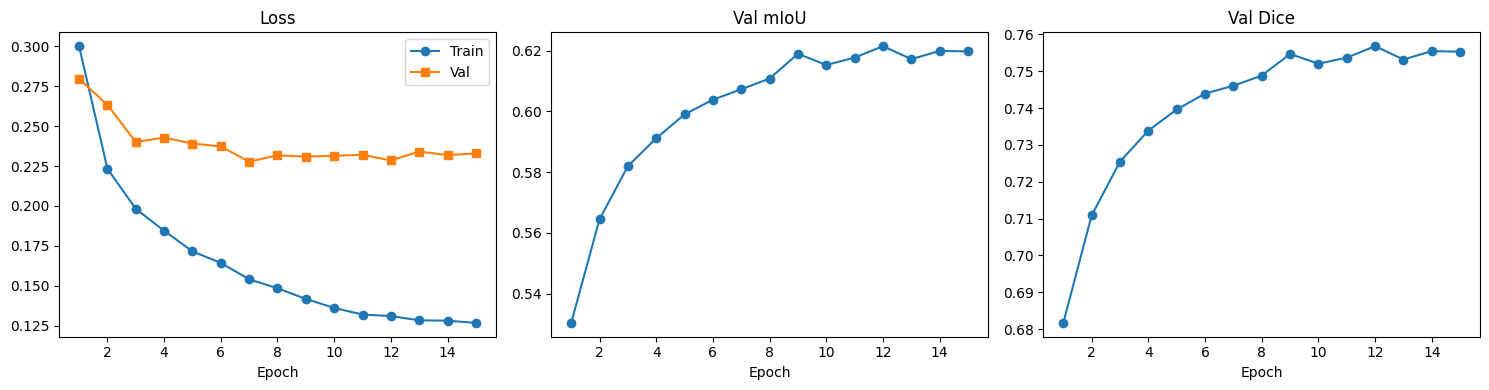

In [30]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   marker="s")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# IoU
axes[1].plot(epochs_range, history["val_iou"], marker="o")
axes[1].set_title("Val mIoU")
axes[1].set_xlabel("Epoch")

# Dice
axes[2].plot(epochs_range, history["val_dice"], marker="o")
axes[2].set_title("Val Dice")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 10. Per-Prompt Evaluation on Test Set

In [31]:
# Load best checkpoint — weights_only=True suppresses FutureWarning in PyTorch ≥2.0
model.load_state_dict(
    torch.load("checkpoints/best_clipseg.pth", map_location=DEVICE, weights_only=True)
)
model.eval()


def evaluate_per_prompt(records, canonical_prompt, label, n_samples=None):
    """
    Evaluate on a list of records with a fixed canonical prompt.
    Returns avg mIoU, avg Dice, avg inference time, and up to 4 sample dicts.
    """
    ious, dices, times = [], [], []
    samples = []

    recs = random.sample(records, min(n_samples, len(records))) if n_samples else records

    with torch.no_grad():
        for rec in tqdm(recs, desc=f"Eval [{label}]"):
            image          = Image.open(rec["image_path"]).convert("RGB")
            orig_w, orig_h = image.size

            enc = processor(
                text=[canonical_prompt],
                images=[image],
                return_tensors="pt",
                padding=True,
            ).to(DEVICE)

            t0  = time.time()
            out = model(**enc)
            t1  = time.time()
            times.append(t1 - t0)

            logits = out.logits
            if logits.dim() == 4:
                logits = logits.squeeze(1)               # → 1 H' W'

            # Resize prediction to original image size
            pred_up = F.interpolate(
                logits.unsqueeze(1),
                size=(orig_h, orig_w),
                mode="bilinear", align_corners=False
            ).squeeze()                                  # → H W  (2-D)

            gt_tensor = torch.tensor(
                rec["mask"].astype(np.float32) / 255.0,
                device=DEVICE
            )                                            # → H W  (2-D)

            # Add batch dim so compute_metrics sees shape (1, H, W)
            iou, dice = compute_metrics(
                pred_up.unsqueeze(0),
                gt_tensor.unsqueeze(0)
            )
            ious.append(iou)
            dices.append(dice)

            if len(samples) < 4:
                pred_bin = (torch.sigmoid(pred_up) > 0.5).cpu().numpy().astype(np.uint8) * 255
                samples.append({
                    "image":    np.array(image),
                    "gt":       rec["mask"],
                    "pred":     pred_bin,
                    "iou":      iou,
                    "dice":     dice,
                    "image_id": rec["image_id"],
                })

    return np.mean(ious), np.mean(dices), np.mean(times), samples


# ── Run evaluation ────────────────────────────────────────────────────────────
drywall_iou, drywall_dice, drywall_time, drywall_samples = evaluate_per_prompt(
    drywall_test, CANONICAL["drywall"], "taping area"
)
crack_iou, crack_dice, crack_time, crack_samples = evaluate_per_prompt(
    crack_test, CANONICAL["crack"], "crack"
)

overall_iou  = (drywall_iou  + crack_iou)  / 2
overall_dice = (drywall_dice + crack_dice) / 2

print("\n" + "=" * 60)
print(f"{'Prompt':<30} {'mIoU':>8} {'Dice':>8} {'Avg t (s)':>10}")
print("-" * 60)
print(f"{'segment taping area':<30} {drywall_iou:>8.4f} {drywall_dice:>8.4f} {drywall_time:>10.3f}")
print(f"{'segment crack':<30} {crack_iou:>8.4f} {crack_dice:>8.4f} {crack_time:>10.3f}")
print("-" * 60)
print(f"{'Overall (mean)':<30} {overall_iou:>8.4f} {overall_dice:>8.4f}")
print("=" * 60)

Eval [crack]: 100%|██████████| 312/312 [00:30<00:00, 10.33it/s]


Prompt                             mIoU     Dice  Avg t (s)
------------------------------------------------------------
segment taping area              0.6211   0.7564      0.022
segment crack                    0.5107   0.6607      0.022
------------------------------------------------------------
Overall (mean)                   0.5659   0.7085


## 11. Visual Examples: orig | GT | pred

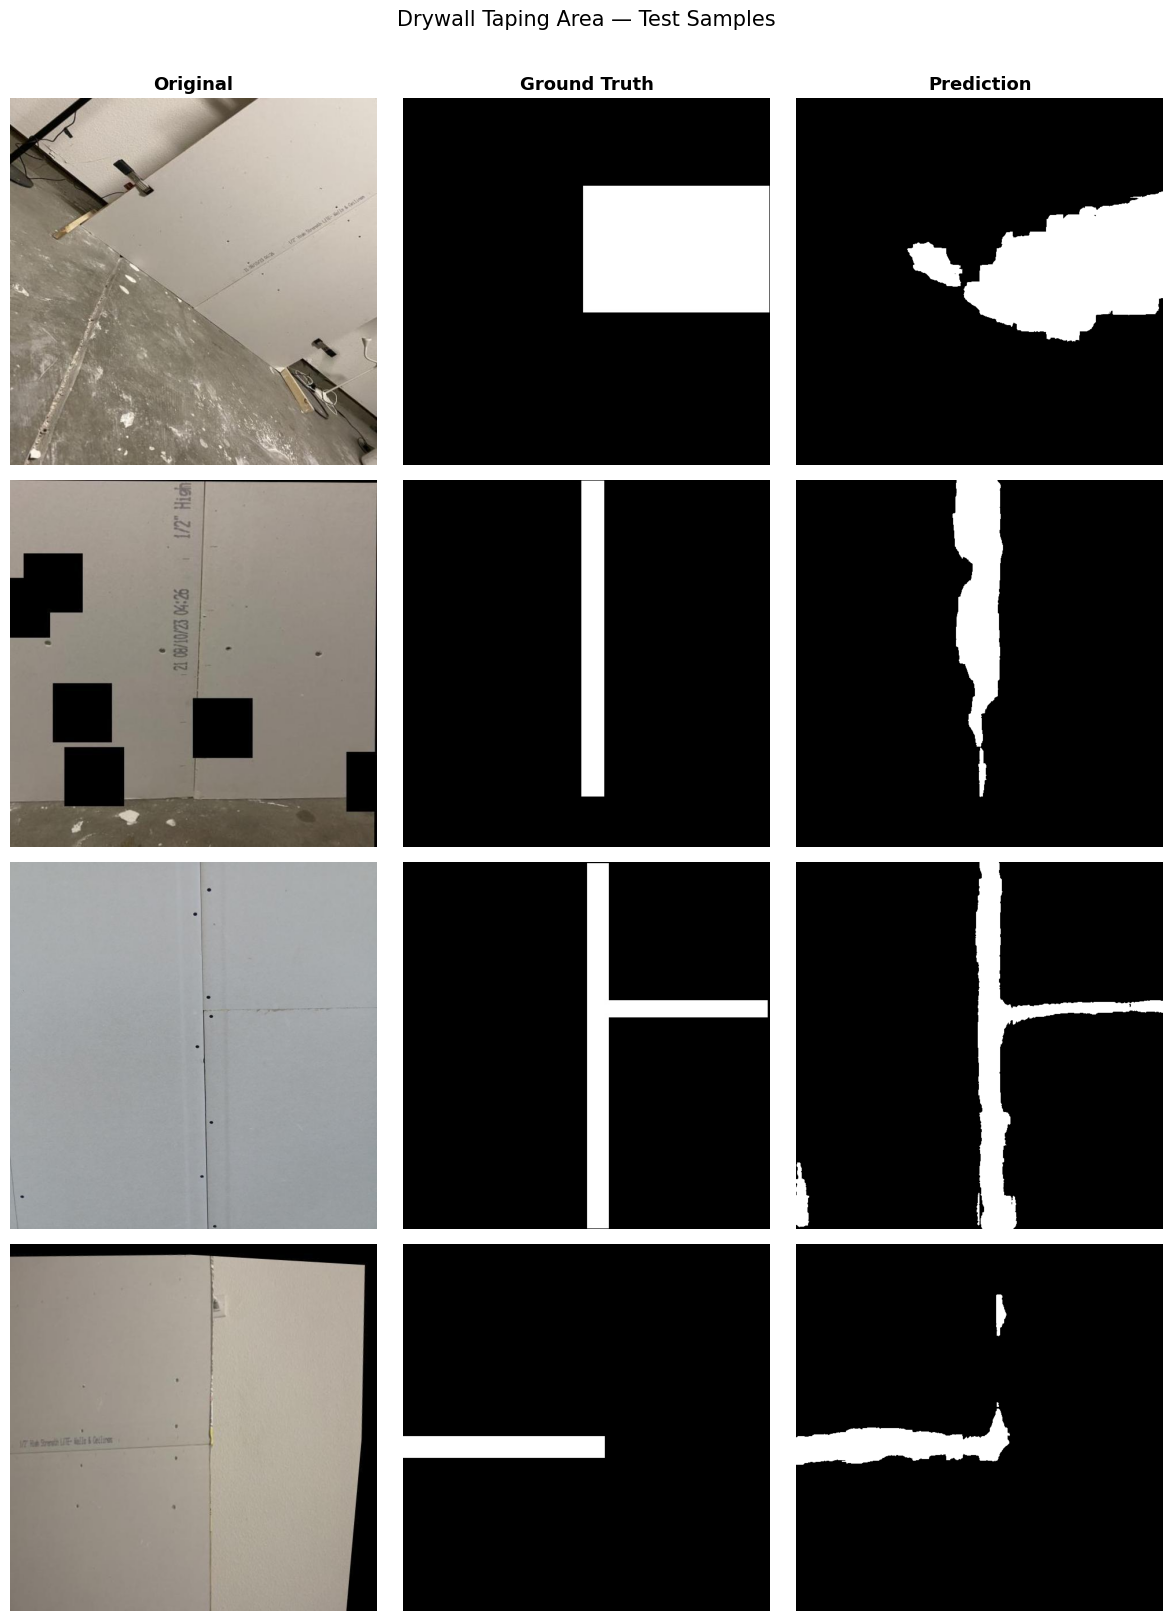

Saved: drywall_taping_area_—_test_samples.png


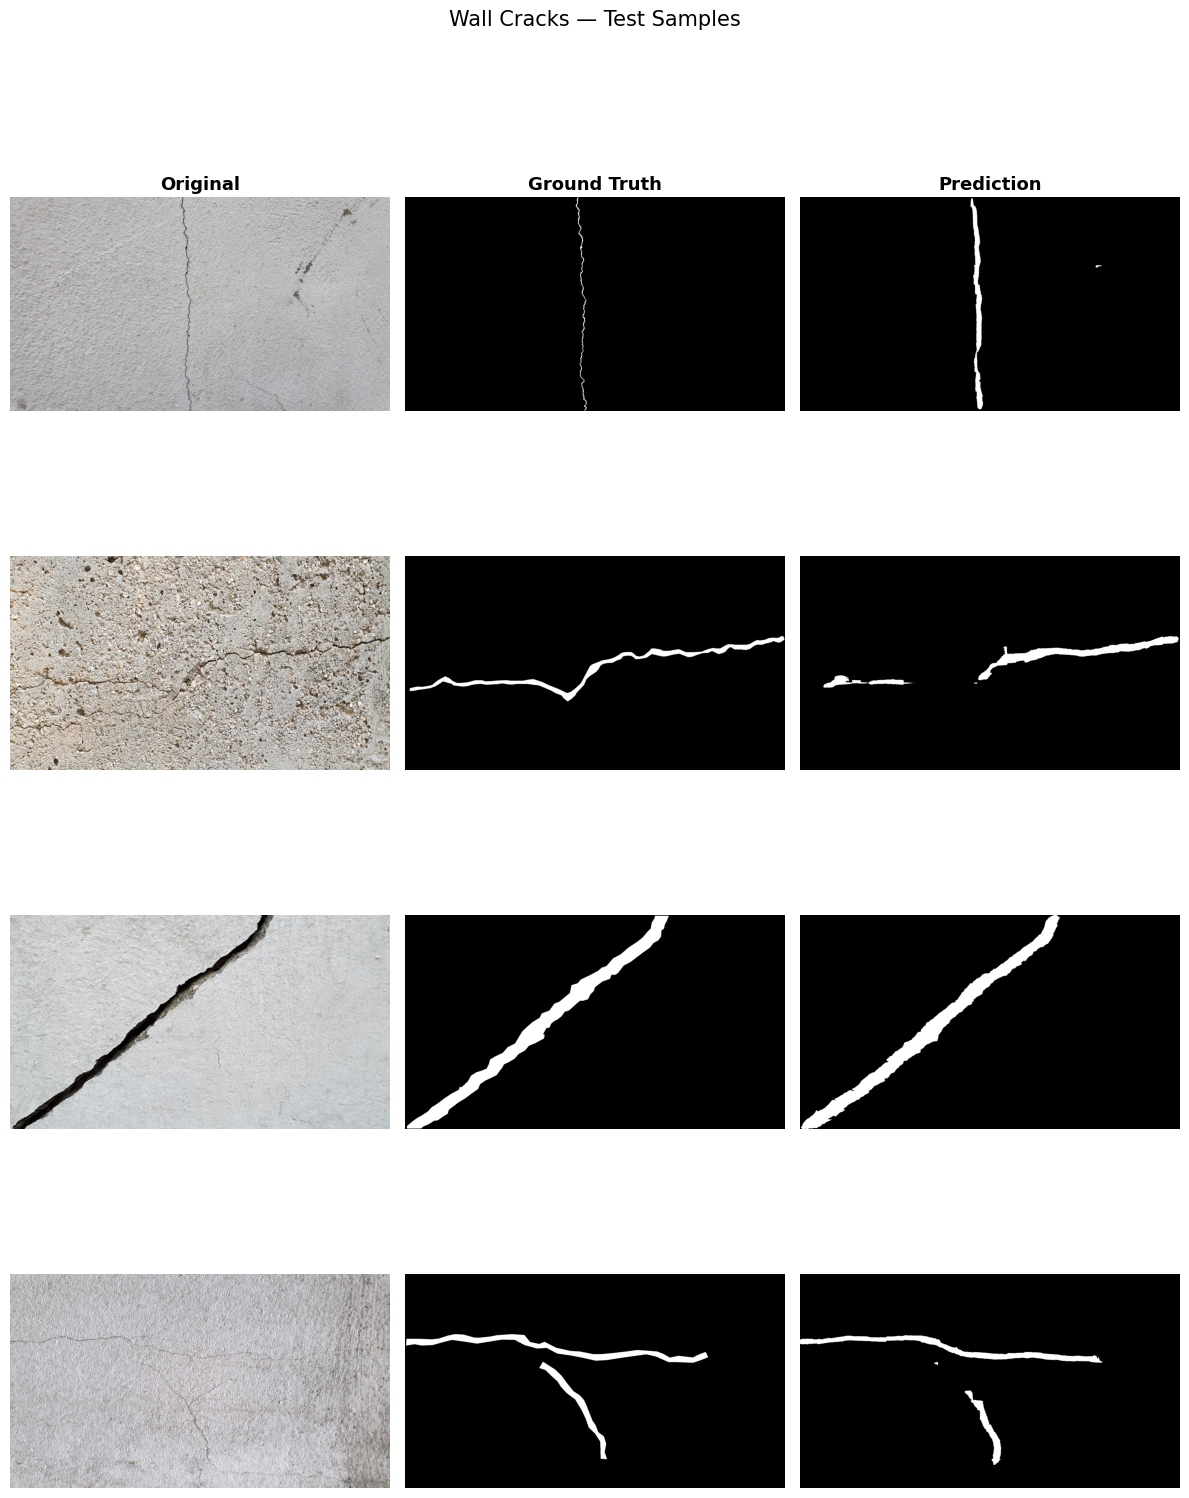

Saved: wall_cracks_—_test_samples.png


In [32]:
def plot_triplets(samples, title):
    n    = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]
    for col, ct in enumerate(["Original", "Ground Truth", "Prediction"]):
        axes[0][col].set_title(ct, fontsize=13, fontweight="bold")

    for i, s in enumerate(samples):
        axes[i][0].imshow(s["image"])
        axes[i][1].imshow(s["gt"],   cmap="gray")
        axes[i][2].imshow(s["pred"], cmap="gray")
        axes[i][0].set_ylabel(
            f"id={s['image_id']}\nIoU={s['iou']:.3f}  Dice={s['dice']:.3f}",
            fontsize=9
        )
        for ax in axes[i]:
            ax.axis("off")

    plt.suptitle(title, fontsize=15, y=1.01)
    plt.tight_layout()
    fname = title.lower().replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


plot_triplets(drywall_samples, "Drywall Taping Area — Test Samples")
plot_triplets(crack_samples,   "Wall Cracks — Test Samples")

## 12. Save Prediction Masks (Required Format)

In [33]:
os.makedirs("prediction_masks", exist_ok=True)


def save_masks(records, canonical_prompt, prompt_slug):
    """
    Saves PNG masks: {image_id}__{prompt_slug}.png
    Single-channel, values {0, 255}, same spatial size as source image.
    """
    model.eval()
    with torch.no_grad():
        for rec in tqdm(records, desc=f"Saving masks [{prompt_slug}]"):
            image          = Image.open(rec["image_path"]).convert("RGB")
            orig_w, orig_h = image.size

            enc = processor(
                text=[canonical_prompt],
                images=[image],
                return_tensors="pt",
                padding=True,
            ).to(DEVICE)

            out    = model(**enc)
            logits = out.logits
            if logits.dim() == 4:
                logits = logits.squeeze(1)               # → 1 H' W'

            # Resize to original dimensions — use view() safe squeeze
            pred_up = F.interpolate(
                logits.unsqueeze(1),
                size=(orig_h, orig_w),
                mode="bilinear", align_corners=False
            )                                            # → 1 1 H W
            pred_up = pred_up.squeeze(0).squeeze(0)     # → H W  (always 2-D)

            pred_bin = ((torch.sigmoid(pred_up) > 0.5).cpu().numpy() * 255).astype(np.uint8)
            out_img  = Image.fromarray(pred_bin, mode="L")

            fname = f"{rec['image_id']}__{prompt_slug}.png"
            out_img.save(os.path.join("prediction_masks", fname))


save_masks(drywall_test, CANONICAL["drywall"], "segment_taping_area")
save_masks(crack_test,   CANONICAL["crack"],   "segment_crack")

saved = os.listdir("prediction_masks")
print(f"\nSaved {len(saved)} prediction masks to ./prediction_masks/")
print("Sample filenames:", saved[:4])

Saving masks [segment_crack]: 100%|██████████| 312/312 [00:45<00:00,  6.81it/s]


Saved 562 prediction masks to ./prediction_masks/
Sample filenames: ['2000x1500_81_resized_jpg.rf.a7fc637816482dd300cd162194703e11.jpg__segment_taping_area.png', '55__segment_crack.png', 'IMG_8276_JPG_jpg.rf.a0bddc49dd43a99381dc1eacc407475c.jpg__segment_taping_area.png', '144__segment_crack.png']


## 13. Model Footprint Summary

In [34]:
ckpt_size_mb = os.path.getsize("checkpoints/best_clipseg.pth") / (1024**2)

print("━" * 50)
print("  RUNTIME & FOOTPRINT SUMMARY")
print("━" * 50)
print(f"  Seed                   : {SEED}")
print(f"  Model                  : {MODEL_NAME}")
print(f"  Total params           : {total:,}")
print(f"  Trainable params       : {trainable:,}")
print(f"  Checkpoint size        : {ckpt_size_mb:.1f} MB")
print(f"  Training time          : {total_train_time / 60:.1f} min  ({EPOCHS} epochs)")
print(f"  Avg inference (drywall): {drywall_time * 1000:.1f} ms/image")
print(f"  Avg inference (crack)  : {crack_time * 1000:.1f} ms/image")
print("━" * 50)
print("  TEST METRICS")
print("━" * 50)
print(f"  segment taping area    →  mIoU: {drywall_iou:.4f}  Dice: {drywall_dice:.4f}")
print(f"  segment crack          →  mIoU: {crack_iou:.4f}  Dice: {crack_dice:.4f}")
print(f"  Overall mean           →  mIoU: {overall_iou:.4f}  Dice: {overall_dice:.4f}")
print("━" * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RUNTIME & FOOTPRINT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Seed                   : 42
  Model                  : CIDAS/clipseg-rd64-refined
  Total params           : 150,747,746
  Trainable params       : 1,127,009
  Checkpoint size        : 575.2 MB
  Training time          : 52.4 min  (15 epochs)
  Avg inference (drywall): 22.3 ms/image
  Avg inference (crack)  : 22.3 ms/image
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TEST METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  segment taping area    →  mIoU: 0.6211  Dice: 0.7564
  segment crack          →  mIoU: 0.5107  Dice: 0.6607
  Overall mean           →  mIoU: 0.5659  Dice: 0.7085
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 14. Zip All Outputs for Download

In [35]:
shutil.make_archive("prediction_masks", "zip", "prediction_masks")
print("prediction_masks.zip created")

shutil.make_archive("checkpoint", "zip", "checkpoints")
print("checkpoint.zip created")

try:
    from google.colab import files
    files.download("prediction_masks.zip")
    files.download("checkpoint.zip")
    files.download("training_curves.png")
    files.download("drywall_taping_area_—_test_samples.png")
    files.download("wall_cracks_—_test_samples.png")
except ImportError:
    print("Not in Colab — files are in the working directory.")

prediction_masks.zip created
checkpoint.zip created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Appendix: Report Snippet

```
MODEL:   CLIPSeg (CIDAS/clipseg-rd64-refined)
         - CLIP ViT image encoder (frozen)
         - CLIP text encoder (frozen)
         - Transformer FiLM decoder (fine-tuned)
         - Paper: Lüddecke & Ecker, CVPR 2022

DATASETS:
  Dataset 1 — Drywall-Join-Detect (objectdetect-pu6rn)
  Dataset 2 — Crack-bphdr (university-bswxt)
  Format: COCO Segmentation → polygon → binary mask

TRAINING:
  Optimizer  : AdamW  lr=3e-4  wd=1e-4
  Scheduler  : CosineAnnealingLR
  Loss       : 0.5×BCE + 0.5×Dice
  Epochs     : 15
  Batch size : 4
  Seed       : 42
  Augment    : random horizontal flip (train only)

PROMPTS (train, augmented):
  Drywall: "segment taping area", "segment joint tape",
           "segment drywall seam", "segment drywall joint"
  Crack:   "segment crack", "segment wall crack",
           "segment surface crack", "segment concrete crack"

CANONICAL EVAL PROMPTS:
  "segment taping area"  |  "segment crack"
```

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Mounted at /content/drive


Model saved to: /content/drive/MyDrive/clipseg_models/best_clipseg.pth
